# Local expmnation of noun phrases of VLM
### Step 1: Generate the concept matix for noun phrases for (crop, concept pair)
### Step 2: Run an inference with an image or without an image. get all the embedding of the noun phrases
### Step 3: Select one embedding corresponds to the noun phrase of step 2 
### Step 4: Project the embedding to the concept matrix and get the corresponding images



## Generate Concept matrix

In [1]:
import torch
import os
import random

In [2]:
# Data dir
data_path = "/mnt/abka03/xlvlm_data/coco_cc0_plus" # Where the raw data exist with class names as a directory # use """" for d in *\ *; do mv "$d" "${d// /_}"; done "" remove space from the class names
cropped_data_path = "/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train" #This path will be created to save the concept crops and crops will be stored


#Output dir

output_dir = "/mnt/abka03/concept_extraction_result/rsml/gemma3n/MCoX/SNMF/mscoco"

# automatically create train and val path inside output_dir
train_output_dir = f"{output_dir}/train"
val_output_dir = f"{output_dir}/val" 
# create the directories if they do not exist

os.makedirs(train_output_dir, exist_ok=True)
os.makedirs(val_output_dir, exist_ok=True)

# inside each of this directory create concept, features directories
concept_train_dir = f"{train_output_dir}/concept"
features_train_dir = f"{train_output_dir}/features"
concept_val_dir = f"{val_output_dir}/concept"
features_val_dir = f"{val_output_dir}/features"
# create the directories if they do not exist

os.makedirs(concept_train_dir, exist_ok=True)
os.makedirs(features_train_dir, exist_ok=True)
os.makedirs(concept_val_dir, exist_ok=True)
os.makedirs(features_val_dir, exist_ok=True)


# use """" for d in *\ *; do mv "$d" "${d// /_}"; done "" remove space from the class names



In [3]:

#Model id from hugingface
model_card = "Qwen/Qwen2.5-VL-7B-Instruct"
#save_the model first in the hugging face path
hugging_face_path = "/mnt/abka03/huggingface/hub/hub" # please load it foirst other wise could throw an error


In [4]:
# Running one time sufficient
training_data_path = f"{data_path}/train"
# create a random crops of trainging data
!python  preprocessing/random_crops.py \
  --input_root $training_data_path \
  --output_root $cropped_data_path \
  --patch_size 150 \
  --patches_per_image 20 \
  --max_overlap 0.5 


In [5]:

#Set huggingface_path 
!export HF_HOME=/mnt/abka03/huggingface/hub


# Get the feature for one image 

# Multiple choice quiestions correct choice concept or Something else
concept_example = "banana" 
# Prompt: 

test_image_dir = f"{data_path}/val/{concept_example}"


# randomly chose one image fom  test_image_path

test_image_path = f"{test_image_dir}/{random.choice(os.listdir(test_image_dir))}"
print("Test image is: ", test_image_path)

!python src/save_features.py \
    --model_name $"{model_card}" \
    --dataset_name "image" \
    --data_dir $"{test_image_path}" \
    --hook_name "save_hidden_states_sentence" \
    --modules_to_hook "model.language_model.norm" \
    --save_dir $"{val_output_dir}" \
    --save_filename "qween2_5" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --token_of_interest $"{concept_example}"\
    --prompt_template "cgdl" \
    --concept $"{concept_example}" \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"


Test image is:  /mnt/abka03/xlvlm_data/coco_cc0_plus/val/banana/466835.jpg
[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:03:40,111 - INFO - Loading model: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:03:40,111 - INFO - Arguments:
2025-08-22 17:03:40,111 - INFO - seed: 0
2025-08-22 17:03:40,111 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:03:40,111 - INFO - processor_name: None
2025-08-22 17:03:40,111 - INFO - local_files_only: False
2025-08-22 17:03:40,111 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-08-22 17:03:40,111 - INFO - prompt_template: cgdl
2025-08-22 17:03:40,111 - INFO - prompt: Describe the image in detail.
2025-08-22 17:03:40,111 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_cc0_plus/val/banana/466835.jpg
2025-08-22 17:03:40,111 - INFO - annotation_file: annotations.json
2025-08-22 17:03:40,111 - INFO - questions_file: annotations.json
2025-08-22 17:03:40,111

In [6]:
# Project the image to the concept and explain 
prediction_path = f"{features_val_dir}/save_hidden_states_sentence_qween2_5.pth"

import sys

script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)

from analysis.feature_decomposition import get_feature_matrix
module_name ="model.language_model.norm"
token_idx = None
output = torch.load(prediction_path)


absolute_features = output["hidden_states"]

feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )



phrase_and_text_prediction = output["model_predictions"]
phrases = [out[0].split("@")[0] for out in phrase_and_text_prediction]
print("Model predcition is: ", output["model_predictions"][0][0].split("@")[0])
print("Phrases are: ", phrases)

test_image_file_name = output["image"]

/mnt/abka03/.conda/envs/rsml3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model predcition is:  banana
Phrases are:  ['banana']


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [7]:
import subprocess

# Define the concept you want to pass


# Run the script with the concept as argument
subprocess.run(
    ["scripts/run_feature_gen_cgdl.sh", model_card, cropped_data_path, train_output_dir, hugging_face_path ],
    cwd='/mnt/abka03/Projects/xl-vlms', 
    check=True
)

[0/10] Processing: airplane (Token: airplane, Concept: "airplane")


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:03:53,892 - INFO - Loading model: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:03:53,892 - INFO - Arguments:
2025-08-22 17:03:53,892 - INFO - seed: 0
2025-08-22 17:03:53,892 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:03:53,892 - INFO - processor_name: None
2025-08-22 17:03:53,892 - INFO - local_files_only: False
2025-08-22 17:03:53,892 - INFO - cache_dir: None
2025-08-22 17:03:53,892 - INFO - prompt_template: cgdl
2025-08-22 17:03:53,892 - INFO - prompt: Describe the image in detail.
2025-08-22 17:03:53,892 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/airplane/
2025-08-22 17:03:53,892 - INFO - annotation_file: annotations.json
2025-08-22 17:03:53,892 - INFO - questions_file: annotations.json
2025-08-22 17:03:53,892 - INFO - answer_type_to_answer: None
2025-08-22 17:03:53,892 - INFO - split: train
2025-08-22

[1/10] Processing: apple (Token: apple, Concept: "apple")


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:04:34,043 - INFO - Loading model: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:04:34,043 - INFO - Arguments:
2025-08-22 17:04:34,043 - INFO - seed: 0
2025-08-22 17:04:34,043 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:04:34,043 - INFO - processor_name: None
2025-08-22 17:04:34,043 - INFO - local_files_only: False
2025-08-22 17:04:34,043 - INFO - cache_dir: None
2025-08-22 17:04:34,043 - INFO - prompt_template: cgdl
2025-08-22 17:04:34,043 - INFO - prompt: Describe the image in detail.
2025-08-22 17:04:34,043 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/apple/
2025-08-22 17:04:34,043 - INFO - annotation_file: annotations.json
2025-08-22 17:04:34,043 - INFO - questions_file: annotations.json
2025-08-22 17:04:34,043 - INFO - answer_type_to_answer: None
2025-08-22 17:04:34,043 - INFO - split: train
2025-08-22 17

[2/10] Processing: backpack (Token: backpack, Concept: "backpack")


...

[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:09:11,994 - INFO - Loading model: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:09:11,994 - INFO - Arguments:
2025-08-22 17:09:11,994 - INFO - seed: 0
2025-08-22 17:09:11,994 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:09:11,994 - INFO - processor_name: None
2025-08-22 17:09:11,994 - INFO - local_files_only: False
2025-08-22 17:09:11,994 - INFO - cache_dir: None
2025-08-22 17:09:11,994 - INFO - prompt_template: cgdl
2025-08-22 17:09:11,994 - INFO - prompt: Describe the image in detail.
2025-08-22 17:09:11,994 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bench/
2025-08-22 17:09:11,994 - INFO - annotation_file: annotations.json
2025-08-22 17:09:11,994 - INFO - questions_file: annotations.json
2025-08-22 17:09:11,994 - INFO - answer_type_to_answer: None
2025-08-22 17:09:11,994 - INFO - split: train
2025-08-22 17

[9/10] Processing: bicycle (Token: bicycle, Concept: "bicycle")


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:09:49,784 - INFO - Loading model: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:09:49,785 - INFO - Arguments:
2025-08-22 17:09:49,785 - INFO - seed: 0
2025-08-22 17:09:49,785 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:09:49,785 - INFO - processor_name: None
2025-08-22 17:09:49,785 - INFO - local_files_only: False
2025-08-22 17:09:49,785 - INFO - cache_dir: None
2025-08-22 17:09:49,785 - INFO - prompt_template: cgdl
2025-08-22 17:09:49,785 - INFO - prompt: Describe the image in detail.
2025-08-22 17:09:49,785 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle/
2025-08-22 17:09:49,785 - INFO - annotation_file: annotations.json
2025-08-22 17:09:49,785 - INFO - questions_file: annotations.json
2025-08-22 17:09:49,785 - INFO - answer_type_to_answer: None
2025-08-22 17:09:49,785 - INFO - split: train
2025-08-22 

Reached maximum number of iterations (10), stopping.

✅ Script completed in 397s (~6 minutes)


CompletedProcess(args=['scripts/run_feature_gen_cgdl.sh', 'Qwen/Qwen2.5-VL-7B-Instruct', '/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train', '/mnt/abka03/concept_extraction_result/rsml/gemma3n/MCoX/SNMF/mscoco/train', '/mnt/abka03/huggingface/hub/hub'], returncode=0)

In [8]:

# Run the script with the concept as argument
subprocess.run(
    ["scripts/run_feature_decompose_cgdl.sh", hugging_face_path, model_card, train_output_dir],
    cwd='/mnt/abka03/Projects/xl-vlms', 
    check=False
)

=== Running decomposition: snmf ===
Processing file: save_hidden_states_sentence_qwen2_patched_image_airplane_token_of_interest_concept_generation_split_train.pth
  - Interpreted concept: save hidden states sentence qwen2 patched image airplane token of interest concept generation split train
  - Analyzing features...


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:10:29,859 - INFO - Arguments:
2025-08-22 17:10:29,859 - INFO - seed: 0
2025-08-22 17:10:29,859 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:10:29,859 - INFO - processor_name: None
2025-08-22 17:10:29,859 - INFO - local_files_only: False
2025-08-22 17:10:29,860 - INFO - cache_dir: None
2025-08-22 17:10:29,860 - INFO - prompt_template: llava
2025-08-22 17:10:29,860 - INFO - prompt: Describe the image in detail.
2025-08-22 17:10:29,860 - INFO - data_dir: data/
2025-08-22 17:10:29,860 - INFO - annotation_file: annotations.json
2025-08-22 17:10:29,860 - INFO - questions_file: annotations.json
2025-08-22 17:10:29,860 - INFO - answer_type_to_answer: None
2025-08-22 17:10:29,860 - INFO - split: train
2025-08-22 17:10:29,860 - INFO - dataset_size: -1
2025-08-22 17:10:29,860 - INFO - dataset_name: coco
2025-08-22 17:10:29,860 - INFO - batch

Matrix stats:
Min: -101.1875 Max: 65.4375
NaNs: 0 Infs: 0
Shape: (270, 3584) Rank: 268


2025-08-22 17:10:36,410 - INFO - 
Decomposition type snmf, Components/concepts shape: (2, 3584), Activations shape: (270, 2)
2025-08-22 17:10:36,535 - INFO - Concept 0 grounded words: []
2025-08-22 17:10:36,535 - INFO - Concept 1 grounded words: ['airplane']
2025-08-22 17:10:36,535 - INFO - Activations size: torch.Size([270, 2])
2025-08-22 17:10:36,535 - INFO - Image paths length: 270
2025-08-22 17:10:36,535 - INFO - Concept 0 image paths: ['UNK@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/airplane/224802_patch_2.png', 'UNK@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/airplane/224802_patch_1.png', 'UNK@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/airplane/418325_patch_1.png']
2025-08-22 17:10:36,535 - INFO - Concept 1 image paths: ['airplane@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/airplane/141834_patch_3.png', 'airplane@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/airplane/283163_patch_5.png', 'airplane@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/tra

Processing file: save_hidden_states_sentence_qwen2_patched_image_apple_token_of_interest_concept_generation_split_train.pth
  - Interpreted concept: save hidden states sentence qwen2 patched image apple token of interest concept generation split train
  - Analyzing features...


...

2025-08-22 17:12:10,335 - INFO - 
Decomposition type snmf, Components/concepts shape: (2, 3584), Activations shape: (270, 2)
2025-08-22 17:12:10,451 - INFO - Concept 0 grounded words: []
2025-08-22 17:12:10,451 - INFO - Concept 1 grounded words: ['bicycle']
2025-08-22 17:12:10,451 - INFO - Activations size: torch.Size([270, 2])
2025-08-22 17:12:10,451 - INFO - Image paths length: 270
2025-08-22 17:12:10,451 - INFO - Concept 0 image paths: ['UNK@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle/199743_patch_8.png', 'UNK@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle/313385_patch_3.png', 'UNK@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle/57879_patch_1.png']
2025-08-22 17:12:10,451 - INFO - Concept 1 image paths: ['bicycle@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle/246833_patch_6.png', 'bicycle@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle/460343_patch_6.png', 'bicycle@/mnt/abka03/xlvlm_data/coco_cc0_plus_cropped/train/bicycle

  - Combining concepts for snmf...
Skipping decompose_activations_text_grounding_image_grounding_snmf_individual_concept_save_hidden_states_sentence_qwen2_patched_image_backpack_token_of_interest_concept_generation_split_train_snmf.pth due to no dominant positive index found/randomly choosen.
Saved combined data to: /mnt/abka03/concept_extraction_result/rsml/gemma3n/MCoX/SNMF/mscoco/train/concept/combined_concept_snmf_raw.pth
Saved combined data to: /mnt/abka03/concept_extraction_result/rsml/gemma3n/MCoX/SNMF/mscoco/train/concept/combined_concept_snmf_gl.pth
  - Cleaning up intermediate files...
  - Regrounding concepts with snmf using normalization: gl


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:12:24,196 - INFO - Arguments:
2025-08-22 17:12:24,196 - INFO - seed: 0
2025-08-22 17:12:24,196 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:12:24,196 - INFO - processor_name: None
2025-08-22 17:12:24,196 - INFO - local_files_only: False
2025-08-22 17:12:24,196 - INFO - cache_dir: None
2025-08-22 17:12:24,196 - INFO - prompt_template: llava
2025-08-22 17:12:24,196 - INFO - prompt: Describe the image in detail.
2025-08-22 17:12:24,196 - INFO - data_dir: data/
2025-08-22 17:12:24,196 - INFO - annotation_file: annotations.json
2025-08-22 17:12:24,196 - INFO - questions_file: annotations.json
2025-08-22 17:12:24,196 - INFO - answer_type_to_answer: None
2025-08-22 17:12:24,196 - INFO - split: train
2025-08-22 17:12:24,196 - INFO - dataset_size: -1
2025-08-22 17:12:24,196 - INFO - dataset_name: coco
2025-08-22 17:12:24,196 - INFO - batch

=== Completed decomposition: snmf ===

All steps completed successfully.
Total execution time: 0h 2m 5s


CompletedProcess(args=['scripts/run_feature_decompose_cgdl.sh', '/mnt/abka03/huggingface/hub/hub', 'Qwen/Qwen2.5-VL-7B-Instruct', '/mnt/abka03/concept_extraction_result/rsml/gemma3n/MCoX/SNMF/mscoco/train'], returncode=0)

## Visualize concept set

In [9]:



font_size = 50
tex_grounding_loc = 0.2


## Local Explantion

In [10]:
# project the image feature to concepts
#import analysis.feature_decomposition as analysis_decomposition


import torch.nn.functional as F
results_filename = f"{concept_train_dir}/combined_concept_snmf_raw.pth" # Path to the results file for concept embeddings
#results_filename = "/mnt/abka03/concept_extraction/CAV/concept_grounding_zca.pth"# Path to the results file for concept embeddings
concept_data = torch.load(results_filename)
analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]

feat_matrix = feat_matrix.float()
projections = feat_matrix @ concept_data["concepts"].T
#projections =  projections / projections.max()
#print(projections.shape)
#can you apply cosign distance
projections = F.cosine_similarity(feat_matrix.unsqueeze(1), concept_data["concepts"].float().unsqueeze(0), dim=-1)
projections = (projections - projections.min()) / (projections.max() - projections.min())

# Normalize feature matrix (feat_matrix) and concept vectors
#feat_matrix = F.normalize(feat_matrix.float(), p=2, dim=1)  # (N, D)
#concepts = F.normalize(concept_data["concepts"].float(), p=2, dim=1)  # (K, D)

# Cosine similarity scaled to [-500, 500]
#projections = (feat_matrix @ concepts.T)
import numpy as np

def find_top_n_powerful_projection(data, n):
    """
    Finds the top n elements for each row along with their indices.

    Parameters:
    - data: List of lists or 2D numpy array.
    - n: Number of top values to find.

    Returns:
    - A list of lists, where each sublist contains tuples of (index, value) 
      representing the top n elements and their indices for the corresponding row.
    """
    # Ensure the input is a numpy array
    data = np.array(data)
    
    # Get the top n indices and values for each row
    top_n_indices = [np.argsort(row)[-n:][::-1] for row in data]
    top_n_pairs = [[(idx, row[idx]) for idx in idxs] for row, idxs in zip(data, top_n_indices)]
    
    return top_n_pairs

n = 4  #mumber of concept to discover 
top_powerful_indexes = find_top_n_powerful_projection(projections, n)

def remap_prjection_image_text(top_powerful_indexes, test_image_path, image_concept_path, phrase_concept_path, text_concept_path):
    if len(top_powerful_indexes) != len(test_image_path):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Image concept path:",len(test_image_path))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_image_path, top_powerful_indexes, ):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs], 'phrase_concept': [phrase_concept_path[i[0]] for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


image_grounding_paths = concept_data["image_grounding_paths"]
phrase_grounding_paths = concept_data['image_grounding_paths']
text_grounding_paths = concept_data["text_grounding"]
test_data_remapped = remap_prjection_image_text(top_powerful_indexes, test_image_file_name, image_grounding_paths, phrase_grounding_paths, text_grounding_paths)



def load_image(file_path):
    ext = os.path.splitext(file_path)[-1].lower()
    if ext == ".dcm":
        pass
        
    elif ext in [".jpeg", ".jpg", ".png"]:
        image = Image.open(file_path)
        return np.array(image)
    else:
        raise ValueError(f"Unsupported file format: {ext}")


def load_image_as_rgb(filepath):
    """
    Load an image (DICOM, PNG, JPG) and return its RGB data as a NumPy array.

    Args:
        filepath (str): Path to the image file.

    Returns:
        np.ndarray: RGB data as a NumPy array.
    """
    # Check file extension
    file_ext = filepath.split(".")[-1].lower()

    if file_ext in ["png", "jpg", "jpeg"]:
        # For PNG or JPG, use Pillow
        image = Image.open(filepath).convert("RGB")  # Ensure it's RGB
        return np.array(image).astype(np.uint8)

    else:
        raise ValueError(f"Unsupported file format: {file_ext}")


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_local_explantion(concept_idx, concept_text, image_paths):
    concept_names_scores = concept_text[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))
    projection_score = concept_names_scores[1].item()
    print("Projection score:", projection_score)   
    # Increase figure height to fit projection score bar
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 5.5))  # Height increased

    # Title row: unique concepts
    #fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Image layout
    gap = 0.01
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs

    for i in range(num_imgs):
        left = tex_grounding_loc + i * (image_width + gap)
        ax = fig.add_axes([left, 0.25, image_width, 0.6])  # Adjusted y-position
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names on the left
    #label_text = f"Concept {concept_idx}:\n" + "\n".join(concept_names_scores[0]) 
    #label_text = f"h{to_superscript('l')}(û{to_subscript(concept_idx)}):\n" + "\n".join(concept_names_scores[0])
    label_text = f"\n".join(concept_names_scores[0])
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=font_size)

    # Add projection score bar (horizontal, centered on 0)
    ax_bar = fig.add_axes([tex_grounding_loc, 0.1, 0.75, 0.05])  # [left, bottom, width, height]
    ax_bar.barh([0], [projection_score], height=0.5, color='red')
    ax_bar.set_xlim([0, 1])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([0, 1])
    ax_bar.set_xticklabels(['0', '1'], fontsize=font_size)
    ax_bar.axvline(0, color='black', linewidth=1)  # center line
    ax_bar.set_title('Projection Score', fontsize=font_size, loc='left')

    # Add value to the right of the bar
    #fig.text(0.88, 0.11, f"{round(projection_score)}", va='center', ha='left', fontsize=font_size)
    
    #plt.savefig(f"/mnt/abka03/Projects/xl-vlms/plots/mcox/local_explanation/grounding_{concept_idx}.svg", format='svg')
    plt.show()


    

def local_explantion(a_test_image,test_data_remapped):
    
# Provide the file path to the image
    image_path = a_test_image.split("@")[1]

    # Read and display the image
    img = load_image_as_rgb(image_path)
    fig = plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap="gray")
    plt.axis('off')  # Optional: Turn off the axis
    plt.show()
    key = a_test_image
    text_concepts = test_data_remapped[key]
    for i in range(n):
         visualize_local_explantion(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )


Image concept path: 1


Phrase at image: banana@/mnt/abka03/xlvlm_data/coco_cc0_plus/val/banana/466835.jpg


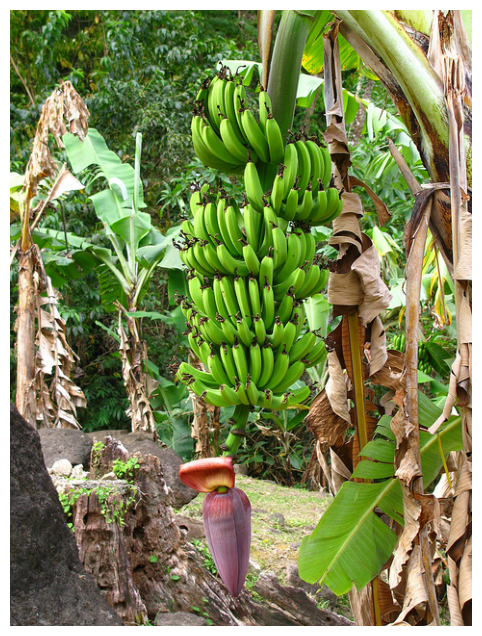

Projection score: 1.0


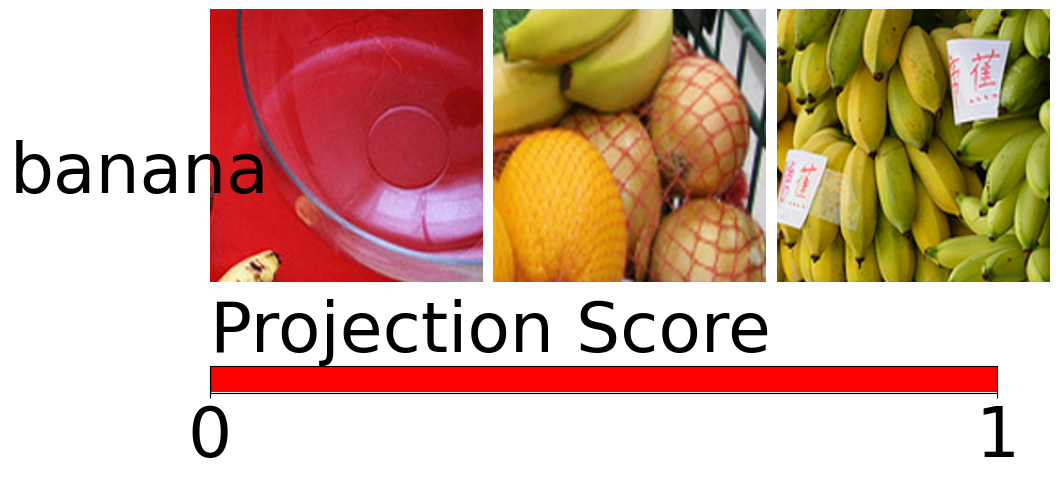

Projection score: 0.7016238570213318


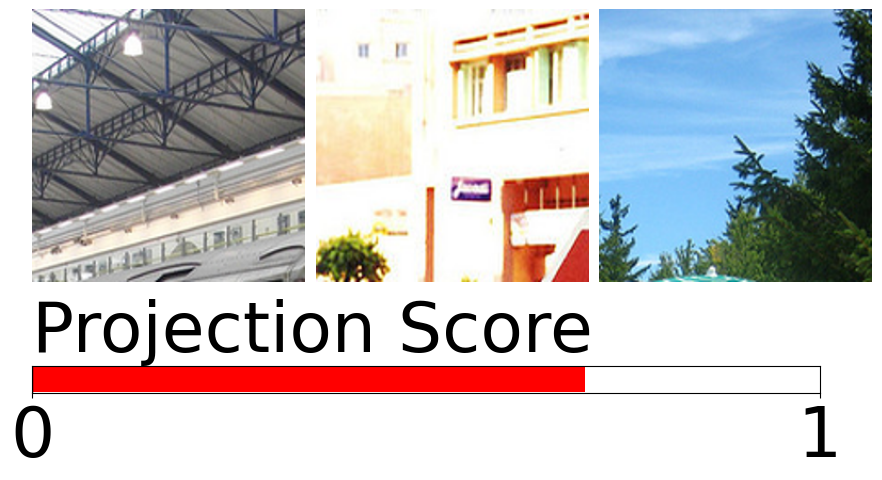

Projection score: 0.6888993382453918


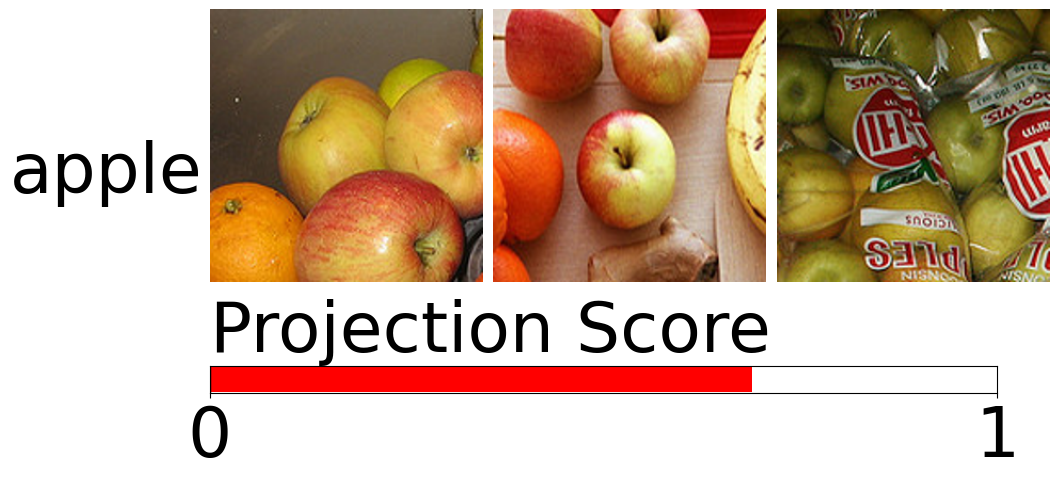

Projection score: 0.5677058100700378


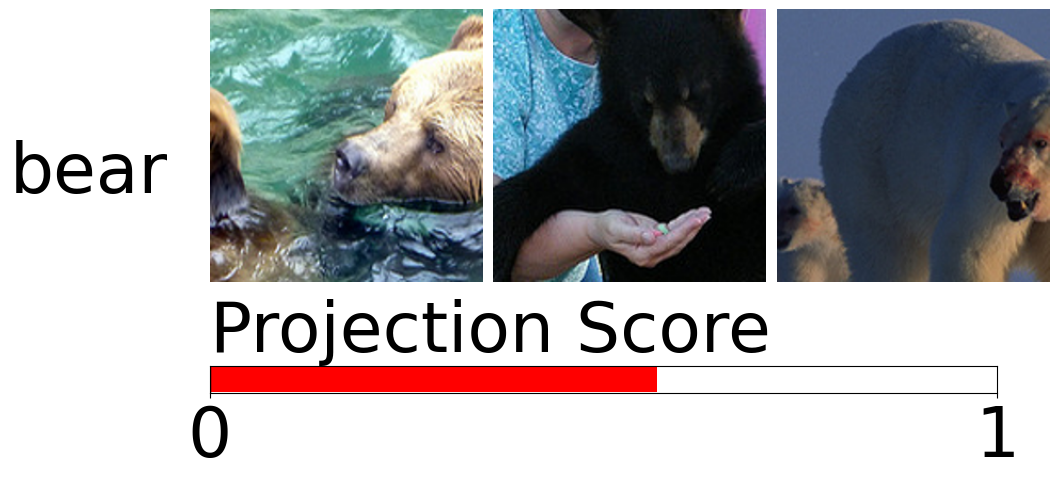

In [11]:
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_image_file_name[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion(a_test_phrase_with_image, test_data_remapped)

## Explain text with images in vlm.
### We have the image concepts

### First get the embedding for a text 



In [12]:
# Get the feature for one image 
concept_name = "bear"


!python src/save_features.py \
    --model_name $"{model_card}" \
    --dataset_name "text" \
    --data_dir $"{concept_name}" \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.language_model.norm" \
    --save_dir $"{val_output_dir}" \
    --save_filename "qwen2_5_text" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --prompt_template "cgdl" \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"

[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 17:12:36,241 - INFO - Loading model: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:12:36,241 - INFO - Arguments:
2025-08-22 17:12:36,241 - INFO - seed: 0
2025-08-22 17:12:36,241 - INFO - model_name_or_path: Qwen/Qwen2.5-VL-7B-Instruct
2025-08-22 17:12:36,241 - INFO - processor_name: None
2025-08-22 17:12:36,241 - INFO - local_files_only: False
2025-08-22 17:12:36,241 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-08-22 17:12:36,241 - INFO - prompt_template: cgdl
2025-08-22 17:12:36,241 - INFO - prompt: Describe the image in detail.
2025-08-22 17:12:36,241 - INFO - data_dir: bear
2025-08-22 17:12:36,241 - INFO - annotation_file: annotations.json
2025-08-22 17:12:36,241 - INFO - questions_file: annotations.json
2025-08-22 17:12:36,241 - INFO - answer_type_to_answer: None
2025-08-22 17:12:36,241 - INFO - split: train
2025-08-22 17:12:36,241 - INFO - dataset_size

In [13]:
text_feature_path = f"{val_output_dir}/features/save_hidden_states_noun_phrase_qwen2_5_text.pth"
output = torch.load(text_feature_path)
#print(output)
absolute_features = output["hidden_states"]
print(output["model_predictions"])



[['bear']]


All text: [['bear']]
Phrase at image: bear


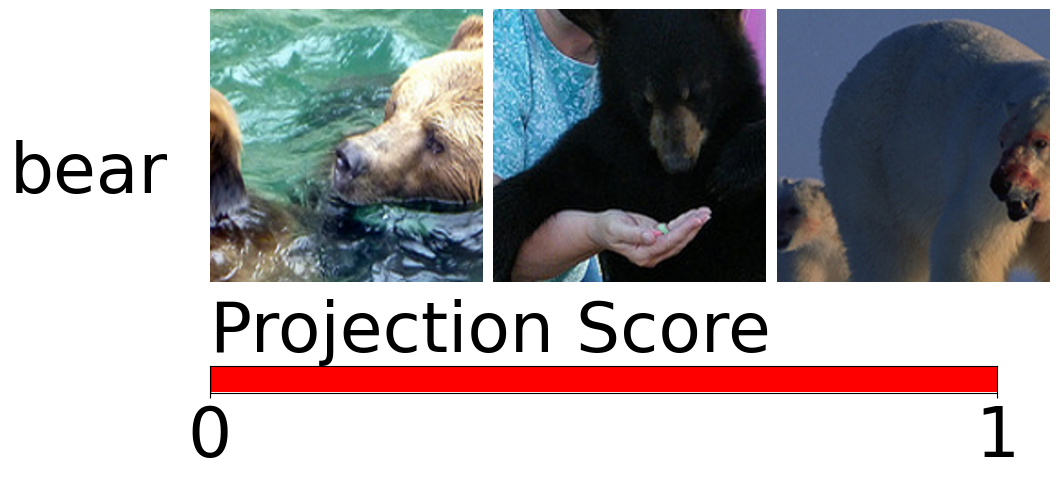

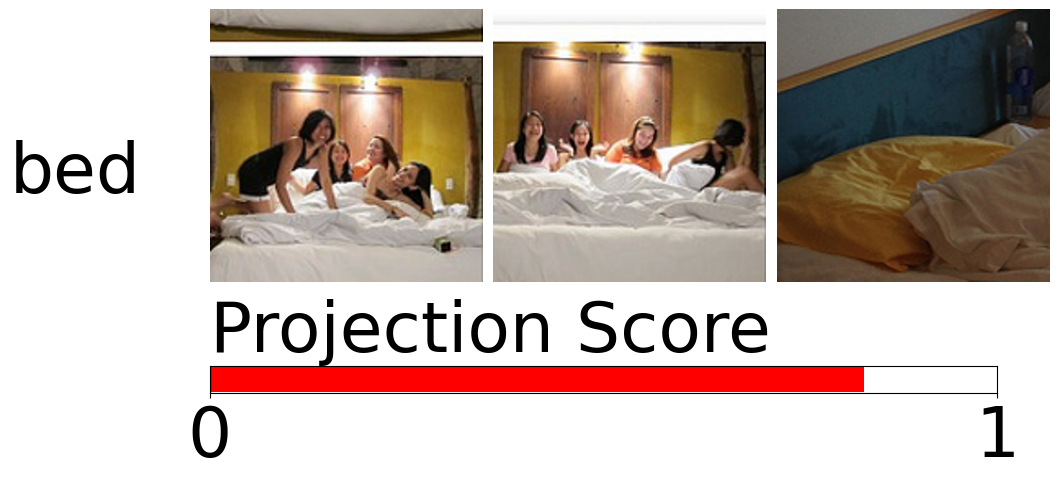

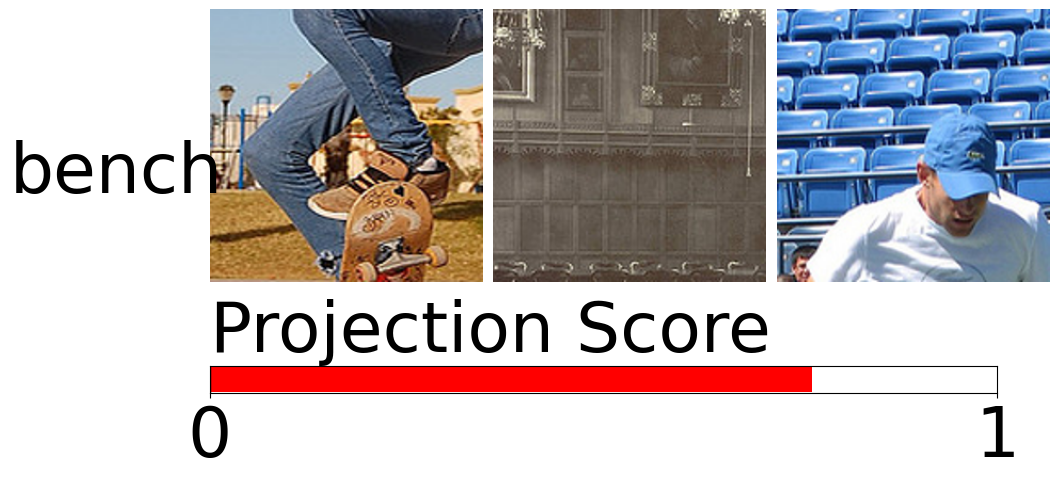

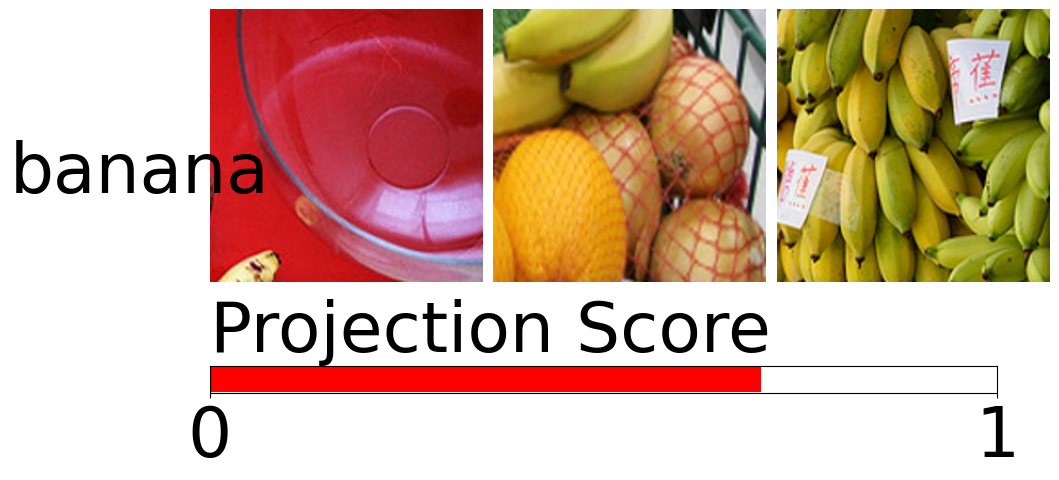

In [14]:
# Project the text in to the concept and explain
from analysis.feature_decomposition import get_feature_matrix
script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)


module_name = 'model.language_model.norm'
token_idx = None
output = torch.load(text_feature_path)
absolute_features = output["hidden_states"]
feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )


analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]
feat_matrix = feat_matrix.float()
#projections = feat_matrix @ concept_data["concepts"].T
#projections = projections / projections.max() 

projections = F.cosine_similarity(feat_matrix.unsqueeze(1), concept_data["concepts"].float().unsqueeze(0), dim=-1)
projections = (projections - projections.min()) / (projections.max() - projections.min()) 

top_powerful_indexes = find_top_n_powerful_projection(projections, n)
test_text = output['model_predictions']
def remap_prjection_text(top_powerful_indexes, test_text, image_concept_path,  text_concept_path):
    if len(top_powerful_indexes) != len(test_text):
        raise ValueError("The projection list and image list of test data not have equal number.")
    

    final_result = {}
    for each_image_path, concept_indexs in zip(test_text, top_powerful_indexes):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


text_grounding_paths = concept_data["text_grounding"]
test_data_remapped_text = remap_prjection_text(top_powerful_indexes, test_text , image_grounding_paths, text_grounding_paths)




def  visualize_grounding_text(concept_idx, concept_text, image_paths):
    concept_names_scores = concept_text[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))
    projection_score = concept_names_scores[1].item()

    # Increase figure height to fit projection score bar
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 5.5))  # Height increased

    # Title row: unique concepts
    #fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Image layout
    gap = 0.01
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs

    for i in range(num_imgs):
        left = tex_grounding_loc + i * (image_width + gap)
        ax = fig.add_axes([left, 0.25, image_width, 0.6])  # Adjusted y-position
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names on the left
    label_text = f""''.join(concept_names_scores[0])
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=font_size)

    # Add projection score bar (horizontal, centered on 0)
    ax_bar = fig.add_axes([0.2, 0.1, 0.75, 0.05])  # [left, bottom, width, height]
    ax_bar.barh([0], [projection_score], height=0.5, color='red')
    ax_bar.set_xlim([0, 1])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([0, 1])
    ax_bar.set_xticklabels(['0', '1'], fontsize=font_size)
    ax_bar.axvline(0, color='black', linewidth=1)  # center line
    ax_bar.set_title('Projection Score', fontsize=font_size, loc='left')

    # Add value to the right of the bar
    #fig.text(0.88, 0.11, f"{round(projection_score)}", va='center', ha='left', fontsize=40)
    #plt.savefig(f"/mnt/abka03/Projects/xl-vlms/plots/mcox/local_explanation/grounding.svg", format='svg')

    plt.show()

n=4
def local_explantion_text(a_test_image,test_data_remapped):
    
    text_concepts = test_data_remapped[a_test_image]
    for i in range(n):
         visualize_grounding_text(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )
test_text = output['model_predictions']
print("All text:", test_text)
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_text[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion_text(a_test_phrase_with_image, test_data_remapped_text )

